# 03 — Physics-informed derivator

This notebook compares strain reconstructed by the PINN with strain obtained from polynomial interpolation (VSG study):

1. run/load an inverse `side_loaded_plate` case using DIC strain data,
2. compare PINN strain against polynomial-interpolated strain and FEM reference.

In [1]:
from pathlib import Path
import importlib

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

from phd.config import load_config
import phd.models.cm.side_loaded_plate as slp
from phd.plot import book_config, get_current_config as plt_cfg
from phd.plot.plot_util import plot_field, add_colorbar

# Ensure notebook uses latest local edits in side_loaded_plate.py
slp = importlib.reload(slp)

book_config.set_as_current()
plot_cfg = plt_cfg()
page_width = plot_cfg.page_width if plot_cfg is not None else 7.0

save_fig = True
if save_fig:
    mpl.rcParams["pgf.texsystem"] = "pdflatex"


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for parent in [current, *current.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise FileNotFoundError("Could not find project root.")


PROJECT_ROOT = find_project_root(Path.cwd())
CHAPTER_DIR = PROJECT_ROOT / "chapters" / "IV_MaterialCharacterization" / "01_side_loaded_plate"
IMAGE_DIR = CHAPTER_DIR / "images"
PDF_DIR = IMAGE_DIR / "pdf"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
PDF_DIR.mkdir(parents=True, exist_ok=True)

DIC_VSG_ROOT = PROJECT_ROOT / "src" / "phd" / "io" / "dataset" / "side_loaded_plate" / "dic_VSG_study"

Using backend: jax
Other supported backends: tensorflow.compat.v1, tensorflow, pytorch, paddle.
paddle supports more examples now and is recommended.
Enable just-in-time compilation with XLA.



In [39]:
def build_dic_inverse_cfg(
    seed: int = 0,
    camera: str = "0.4MP",
    noise: int = 1,
    sample_id: int = 0,
    save_fields: bool = True,
):
    cfg = load_config("side_loaded_plate")

    cfg.seed = seed
    cfg.task.type = "inverse"

    cfg.problem.material.law = "isotropic"
    cfg.problem.geometry.length = 100.0
    cfg.problem.loading.m = 0.3
    cfg.problem.loading.b = 50.0

    cfg.model.net_type = "SPINN"
    cfg.model.formulation = "mixed"
    cfg.model.architecture.n_hidden = 5
    cfg.model.architecture.width = 32
    cfg.model.architecture.rank = 32
    cfg.model.architecture.mlp_type = "modified_mlp"

    cfg.training.n_iter = 30000
    cfg.training.lr = 1e-3
    cfg.training.lr_decay = ["warmup cosine", 1e-4, 1e-3, 1000, 30000, 1e-4]
    cfg.training.log_every = 250
    cfg.training.num_domain = 150 ** 2
    cfg.training.coord_normalization = True
    cfg.training.stress_bc = True
    cfg.training.self_attention.enabled = False
    # cfg.training.loss_weights = [1.0]*5 + [1e2]*2
    cfg.training.loss_normalization.scheme = "grad_norm"

    cfg.task.inverse.measurements.source = "dic"
    cfg.task.inverse.measurements.type = "displacement"
    cfg.task.inverse.measurements.dic.path = f"side_loaded_plate/dic/{camera}/{noise}noise"
    cfg.task.inverse.measurements.dic.sample_id = int(sample_id)
    cfg.task.inverse.measurements.noise_ratio = 0.0

    cfg.results.base_dir = str(PROJECT_ROOT / "results")
    cfg.results.save_on_disk = False
    cfg.results.experiment_name = None

    if save_fields:
        cfg.problem.log_fields = ["Ux", "Uy", "Exx", "Eyy", "Exy", "Sxx", "Syy", "Sxy"]
    else:
        cfg.problem.log_fields = []

    return cfg


def read_csv(path: Path) -> np.ndarray:
    return pd.read_csv(path, sep=None, engine="python", header=None).dropna(axis=1).to_numpy()


def load_vsg_field(camera: str, sw: int, field: str):
    camera_root = DIC_VSG_ROOT / camera
    x_grid = read_csv(camera_root / "x.csv")
    y_grid = read_csv(camera_root / "y.csv")
    field_grid = read_csv(camera_root / str(sw) / f"{field}.csv")
    return x_grid, y_grid, field_grid

In [ ]:
# 1) Produce/load inverse PINN results by camera (simple loop + continuation training)
camera_list = ["5MP", "2MP", "0.4MP"]
camera_to_run = ["5MP"]  # cameras in this list are trained now; others are loaded

noise_meas = 1
sample_meas = 1

results_by_camera = {}
run_dirs_by_camera = {}

for cam in camera_list:
    run_name = f"strain_reconstruction/{cam}"

    if cam in camera_to_run:
        cfg = build_dic_inverse_cfg(
            seed=0,
            camera=cam,
            noise=noise_meas,
            sample_id=sample_meas,
            save_fields=True,
        )

        results_cam = slp.train(cfg)
        run_dir_cam = Path(slp.save_run_data(results_cam, run_name=run_name))
    else:
        try:
            results_cam = slp.load_run(run_name)
            run_dir_cam = Path(results_cam["run_dir"] )
        except FileNotFoundError as exc:
            raise FileNotFoundError(
                f"No saved run found for camera '{cam}' at run_name='{run_name}'. "
                f"Add '{cam}' to camera_to_run or run it once before loading."
            ) from exc

    results_by_camera[cam] = results_cam
    run_dirs_by_camera[cam] = run_dir_cam

print(f"camera_to_run: {camera_to_run}")
for cam in camera_list:
    mode = "run" if cam in camera_to_run else "load"
    print(f"{cam}: {mode} -> {run_dirs_by_camera[cam]}")

Set the default automatic differentiation to forward mode.
Compiling model...
'compile' took 0.181512 s

Training model...

Step      Train loss                                                                Test loss                                                                 Test metric   
0         [1.29e-08, 1.89e-07, 4.14e+03, 4.58e-01, 1.57e-01, 1.27e+00, 1.41e+00]    [1.29e-08, 1.89e-07, 4.14e+03, 4.58e-01, 1.57e-01, 1.27e+00, 1.41e+00]    [6.55e-02]    
100       [3.24e-05, 5.43e-05, 2.03e+03, 1.42e+02, 4.47e+01, 3.96e-01, 2.15e+00]    [3.24e-05, 5.43e-05, 2.03e+03, 1.42e+02, 4.47e+01, 3.96e-01, 2.15e+00]    [6.57e-02]    

Best model at step 100:
  train loss: 2.22e+03
  test loss: 2.22e+03
  test metric: [6.57e-02]

'train' took 30.600608 s

Applying loss weighting scheme: grad_norm
  base_loss_weights=[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
  grad_norms=[0.0002153894311049953, 0.00030574400443583727, 4776.021484375, 916.3300170898438, 247.77633666992188, 1.779903769493103, 4

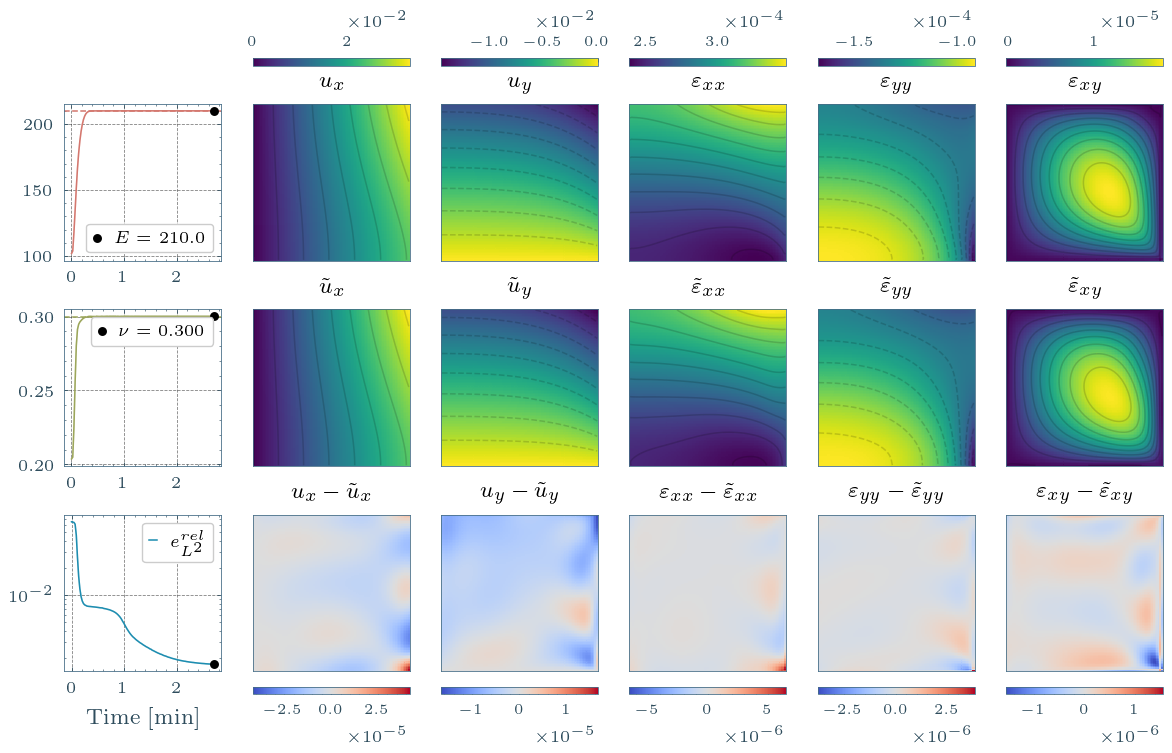

In [47]:
# Plot and save the single-run results (now supports strain fields too)
res_to_plot = "5MP"
fig, artists = slp.plot_results(
    results_by_camera[res_to_plot],
    iteration=-1,
    step_type="time",
    time_unit="min",
    fields=["Ux", "Uy", "Exx", "Eyy", "Exy"],
    plot_contours=True,
    dpi=200,
    show_metrics=True,
    show_residual=True,
    show_iter=False,
    metrics=["L2 Error"],
)
plt.show()

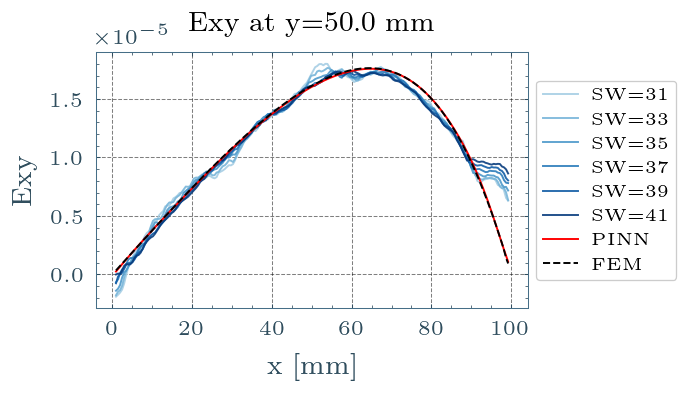

In [48]:
# 2) Compare PINN strain vs polynomial interpolation (VSG study) and FEM
field_name = "Exy"  # Exx, Eyy, Exy
res_to_plot = "5MP"
y_slice = 50.0  # mm

sw_dirs = sorted([int(p.name) for p in (DIC_VSG_ROOT / res_to_plot).iterdir() if p.is_dir() and p.name.isdigit()])
if not sw_dirs:
    raise ValueError(f"No VSG windows found in {(DIC_VSG_ROOT / res_to_plot)}")

extracted = slp.extract_fields_at_iterations(results_by_camera[res_to_plot], iterations=[-1], field_names=[field_name])
if field_name not in extracted["pred"] or field_name not in extracted["exact"]:
    raise KeyError(
        f"Field '{field_name}' is not available in extracted data. "
        f"Pred keys: {list(extracted['pred'].keys())}, exact keys: {list(extracted['exact'].keys())}."
    )

pinn_grid = extracted["pred"][field_name][0]
fem_grid = extracted["exact"][field_name]
X_pinn = extracted["X"]
Y_pinn = extracted["Y"]

x_axis_pinn = X_pinn[:, 0]
y_axis_pinn = Y_pinn[0, :]

interp_pinn = RegularGridInterpolator((x_axis_pinn, y_axis_pinn), pinn_grid, bounds_error=False, fill_value=np.nan)
interp_fem = RegularGridInterpolator((x_axis_pinn, y_axis_pinn), fem_grid, bounds_error=False, fill_value=np.nan)

fig, ax = plt.subplots(1, 1, figsize=(0.6 * page_width, 0.35 * page_width), dpi=250)

field_map = {"Exx": "exx", "Eyy": "eyy", "Exy": "exy"}
poly_field_name = field_map[field_name]

sw_colors = plt.get_cmap("Blues")(np.linspace(0.35, 0.95, len(sw_dirs)))

x_line = None
pinn_line = None
fem_line = None
for i, sw in enumerate(sw_dirs):
    X_poly, Y_poly, poly_grid = load_vsg_field(res_to_plot, sw, poly_field_name)

    y_idx = np.abs(Y_poly[:, 0] - y_slice).argmin()
    x_line = X_poly[y_idx, :]
    y_line = Y_poly[y_idx, :]
    points_line = np.column_stack([x_line, y_line])

    pinn_line = interp_pinn(points_line)
    fem_line = interp_fem(points_line)

    ax.plot(
        x_line,
        poly_grid[y_idx, :],
        color=sw_colors[i],
        alpha=0.9,
        label=f"SW={sw}",
    )

if x_line is None or pinn_line is None or fem_line is None:
    raise RuntimeError("No comparison lines were generated from VSG data.")

ax.plot(x_line, pinn_line, color="r", label="PINN")
ax.plot(x_line, fem_line, color="k", linestyle="--", label="FEM")
ax.set_title(f"{field_name} at y={y_slice:.1f} mm")
ax.set_xlabel("x [mm]")
ax.set_ylabel(field_name)
legend = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=plt_cfg().min_font_size)
cfg = plt_cfg()
legend.get_frame().set_linewidth(cfg.scale if cfg is not None else 1.0)

plt.tight_layout()
plt.show()

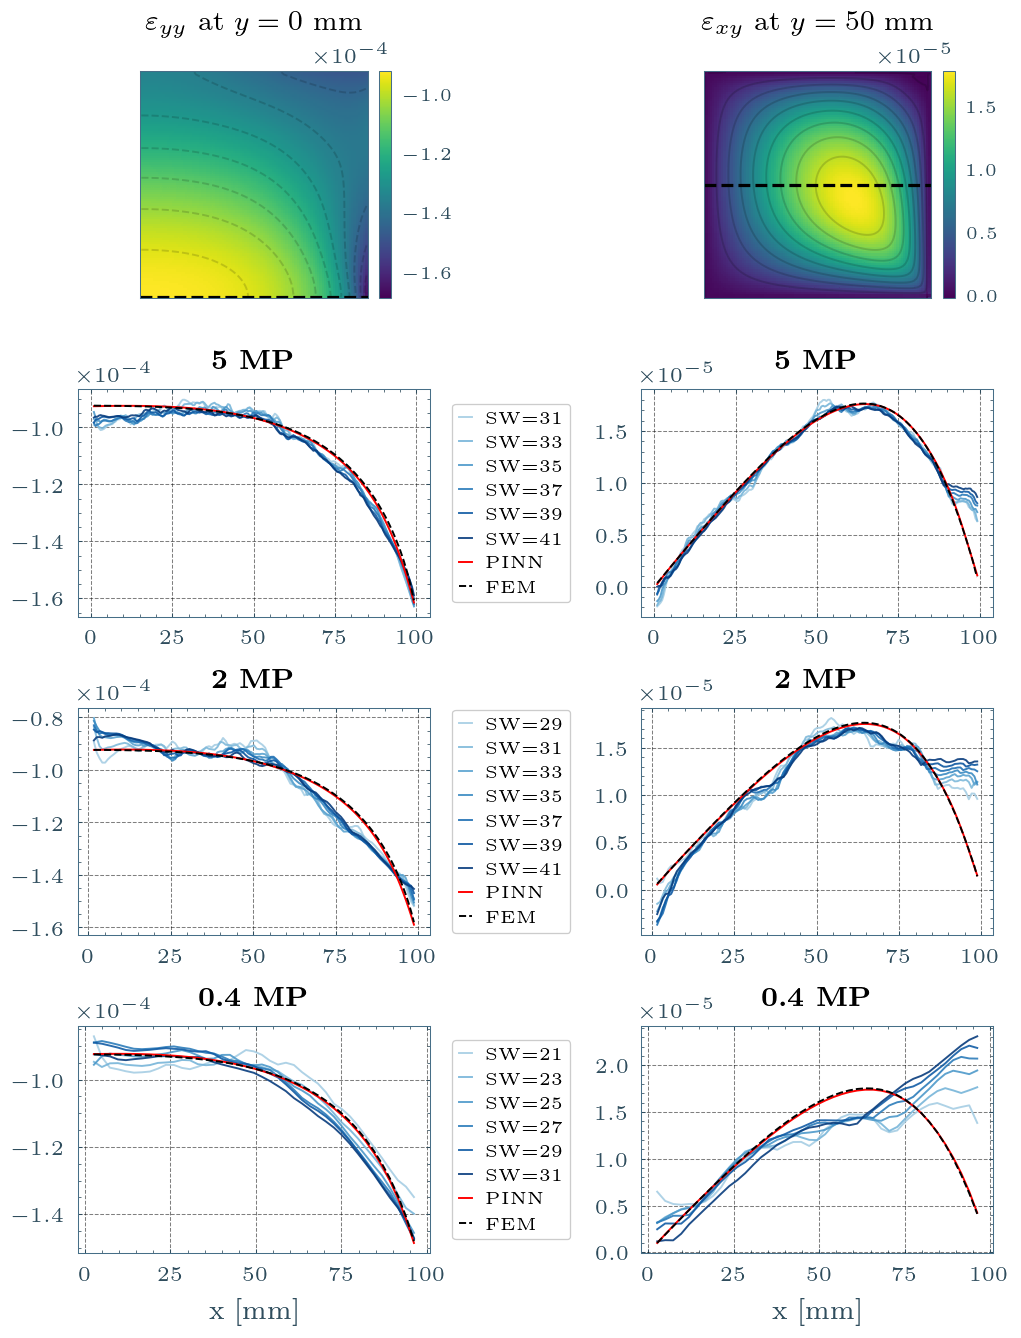

Saved: /home/r2d2/code/PhD/chapters/IV_MaterialCharacterization/01_side_loaded_plate/images/strain_reconstruction_comparison.png
Saved: /home/r2d2/code/PhD/chapters/IV_MaterialCharacterization/01_side_loaded_plate/images/pdf/strain_reconstruction_comparison.pdf


In [50]:
# 3) Old-style composite plot: Eyy@y=0 and Exy@y=50 side-by-side
field_specs = [
    {"field": "Eyy", "slice_y": 0.0, "poly": "eyy", "title": r"$\varepsilon_{yy}$ at $y=0$ mm"},
    {"field": "Exy", "slice_y": 50.0, "poly": "exy", "title": r"$\varepsilon_{xy}$ at $y=50$ mm"},
]
camera_list = ["5MP", "2MP", "0.4MP"]
res_to_plot = "2MP"  # reference camera used for top-row FEM maps

res_latex = {
    "5MP": r"\textbf{5 MP}",
    "2MP": r"\textbf{2 MP}",
    "0.4MP": r"\textbf{0.4 MP}",
}

cfg_plot = plt_cfg()
plot_scale = cfg_plot.scale if cfg_plot is not None else 1.0
legend_font = cfg_plot.min_font_size if cfg_plot is not None else 8

fig, axs = plt.subplots(
    4,
    2,
    figsize=(page_width, 1.3 * page_width),
    dpi=250,
    gridspec_kw={
        "height_ratios": [1] + [1]*3,
        "wspace": 0.6,
        "hspace": 0.4,
    },
)

row_legend_items = {row: {} for row in range(1, len(camera_list) + 1)}

for col, spec in enumerate(field_specs):
    field_name = spec["field"]
    y_slice_local = spec["slice_y"]
    poly_field_name = spec["poly"]

    # Top-row FEM reference from selected reference camera model
    extracted_ref = slp.extract_fields_at_iterations(results_by_camera[res_to_plot], iterations=[-1], field_names=[field_name])
    fem_grid_ref = extracted_ref["exact"][field_name]
    X_ref = extracted_ref["X"]
    Y_ref = extracted_ref["Y"]

    art = plot_field(
        axs[0, col],
        X_ref,
        Y_ref,
        fem_grid_ref,
        title=spec["title"],
        cmap="viridis",
        plot_contours=True,
    )
    axs[0, col].set_title(spec["title"], pad=12)  # move title up to avoid overlap with colorbar exponent
    add_colorbar(fig, axs[0, col], art["im"])
    axs[0, col].axhline(y=y_slice_local, color="k", linestyle="--", lw=plot_scale * 2.5)
    axs[0, col].set_xticks([])
    axs[0, col].set_yticks([])

    # Rows 2-4: camera resolutions (each row uses its own model run/load result)
    for row, camera in enumerate(camera_list, start=1):
        ax = axs[row, col]
        if camera not in results_by_camera:
            raise ValueError(f"Missing model results for camera '{camera}'.")

        extracted_cam = slp.extract_fields_at_iterations(results_by_camera[camera], iterations=[-1], field_names=[field_name])
        pinn_grid_cam = extracted_cam["pred"][field_name][0]
        fem_grid_cam = extracted_cam["exact"][field_name]
        X_pinn_cam = extracted_cam["X"]
        Y_pinn_cam = extracted_cam["Y"]

        x_axis_pinn = X_pinn_cam[:, 0]
        y_axis_pinn = Y_pinn_cam[0, :]
        interp_pinn = RegularGridInterpolator((x_axis_pinn, y_axis_pinn), pinn_grid_cam, bounds_error=False, fill_value=np.nan)
        interp_fem = RegularGridInterpolator((x_axis_pinn, y_axis_pinn), fem_grid_cam, bounds_error=False, fill_value=np.nan)

        sw_dirs = sorted([int(p.name) for p in (DIC_VSG_ROOT / camera).iterdir() if p.is_dir() and p.name.isdigit()])
        sw_colors = plt.get_cmap("Blues")(np.linspace(0.35, 0.95, len(sw_dirs)))

        x_line = None
        pinn_line = None
        fem_line = None
        for i, sw in enumerate(sw_dirs):
            X_poly, Y_poly, poly_grid = load_vsg_field(camera, sw, poly_field_name)

            y_idx = np.abs(Y_poly[:, 0] - y_slice_local).argmin()
            x_line = X_poly[y_idx, :]
            y_line = Y_poly[y_idx, :]
            points_line = np.column_stack([x_line, y_line])

            pinn_line = interp_pinn(points_line)
            fem_line = interp_fem(points_line)

            line_sw, = ax.plot(
                x_line,
                poly_grid[y_idx, :],
                color=sw_colors[i],
                alpha=0.9,
                label=f"SW={sw}",
            )
            row_legend_items[row].setdefault(f"SW={sw}", line_sw)

        if x_line is None or pinn_line is None or fem_line is None:
            raise RuntimeError(f"No VSG lines generated for camera {camera} and field {field_name}.")

        line_pinn, = ax.plot(x_line, pinn_line, color="r", label="PINN")
        line_fem, = ax.plot(x_line, fem_line, color="k", linestyle="--", label="FEM")
        row_legend_items[row].setdefault("PINN", line_pinn)
        row_legend_items[row].setdefault("FEM", line_fem)

        # Use camera resolution as bold title on both plots of the row
        ax.set_title(res_latex[camera])

        if row == 3:
            ax.set_xlabel("x [mm]")
        ax.ticklabel_format(style='sci', axis='y', scilimits=(-3, 3))

# One legend per resolution row, centered between both columns for that row
for row in range(1, len(camera_list) + 1):
    labels = list(row_legend_items[row].keys())
    handles = [row_legend_items[row][label] for label in labels]
    if not handles:
        continue

    left_pos = axs[row, 0].get_position()
    right_pos = axs[row, 1].get_position()
    x_mid = 0.48 * (left_pos.x1 + right_pos.x0)
    y_mid = 0.5 * (left_pos.y0 + left_pos.y1)

    fig.legend(
        handles,
        labels,
        handlelength=0.75,
        loc="center",
        bbox_to_anchor=(x_mid, y_mid),
        ncol=1,
        frameon=True,
        fontsize=legend_font,
    ).get_frame().set_linewidth(plot_scale)

# plt.tight_layout()
plt.show()

if save_fig:
    fig_name = "strain_reconstruction_comparison"
    fig.savefig(IMAGE_DIR / f"{fig_name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(PDF_DIR / f"{fig_name}.pdf", bbox_inches="tight")
    print(f"Saved: {IMAGE_DIR / (fig_name + '.png')}")
    print(f"Saved: {PDF_DIR / (fig_name + '.pdf')}")